# Split-Chain oPool Library Design

Design 4 combinatorial oPool libraries (alpha/beta × DRG/GIG) for shuffled chain pairing.

## Design principle

Positions with high composite enrichment scores are varied simultaneously across oligos.
At every varied position the IUPAC codon is chosen to guarantee both **WT** and the
**top enriched AA**, with any additional bystander AAs selected to maximise the mean
composite score across all residues the codon happens to encode.

**Enrichment metric:** `enrich_pos1x_vs_neg`; GIG02 uses `enrich_pos2x_vs_neg`.  
**Synergy bonus:** E = observed_log2fc_dev − (marginal_α + marginal_β).

## Oligo tiers
| Tier | Description |
|------|-------------|
| tier1_backbone | Top positions by composite score, always co-varied — sets backbone diversity |
| tier2_ext | One oligo per extension position: Tier 1 + one additional position |
| tier3 | No viable IUPAC codon found; position stays at WT in all combinatorial oligos |

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from itertools import product
import warnings
warnings.filterwarnings('ignore')

NB_DIR   = Path('/cluster/project/reddy/marluca/NGS_pipeline/notebooks')
DATA_DIR = Path('/cluster/project/reddy/marluca/NGS_pipeline/data/P3620_LUCA-TCRDMF5-abDMS/04_variant_labeling')
OUT_DIR  = NB_DIR / 'opool_designs'
OUT_DIR.mkdir(exist_ok=True)
print(f'Output: {OUT_DIR}')

Output: /cluster/project/reddy/marluca/NGS_pipeline/notebooks/opool_designs


In [38]:
PEPTIDES = ['DRG01','DRG02','DRG03','DRG04','GIG01','GIG02','GIG03','GIG04','GIG05']

WT_ALPHA  = 'AVNFGGGKLI'
WT_BETA   = 'ASSLSFGTEAF'
ALPHA_LEN = len(WT_ALPHA)
BETA_LEN  = len(WT_BETA)

ENRICHMENT_COL = {p: 'enrich_pos1x_vs_neg' for p in PEPTIDES}
ENRICHMENT_COL['GIG02'] = 'enrich_pos2x_vs_neg'
PSEUDOCOUNT = 1e-3

# ── Design parameters ────────────────────────────────────────────────────
TARGET_CROSS_DIV  = 1_000_000   # soft target: alpha_div × beta_div ≈ this
MAX_CROSS_DIV     = 10_000_000  # hard cap on cross-diversity
MIN_SCORE         = 0.3    # min composite score to include a position as a candidate
K_MAX             = 8      # max candidate AAs pulled per position (pre-filter)
SYN_WEIGHT        = 0.5    # weight of synergy bonus in composite score
TIER1_FRAC        = 0.33   # backbone diversity cap as fraction of per-chain target; raise to co-vary more positions, lower for more extensions

STOP_PENALTY      = 10.0   # subtracted from mean score per unit stop-codon fraction
EFFICIENCY_THRESH = 0.3    # must-have fraction below which an oligo is flagged leaky

print(f'Alpha WT: {WT_ALPHA}  ({ALPHA_LEN} aa)')
print(f'Beta  WT: {WT_BETA}  ({BETA_LEN} aa)')
print(f'{len(PEPTIDES)} peptides: {PEPTIDES}')
print(f'Cross-diversity target: {TARGET_CROSS_DIV:,}  (hard cap: {MAX_CROSS_DIV:,})')
print(f'Tier1 backbone cap: {TIER1_FRAC:.0%} of per-chain target')

Alpha WT: AVNFGGGKLI  (10 aa)
Beta  WT: ASSLSFGTEAF  (11 aa)
9 peptides: ['DRG01', 'DRG02', 'DRG03', 'DRG04', 'GIG01', 'GIG02', 'GIG03', 'GIG04', 'GIG05']
Cross-diversity target: 1,000,000  (hard cap: 10,000,000)
Tier1 backbone cap: 33% of per-chain target


## Genetic Code and IUPAC Utilities

In [39]:
GENETIC_CODE = {
    'ATA':'I','ATC':'I','ATT':'I','ATG':'M',
    'ACA':'T','ACC':'T','ACG':'T','ACT':'T',
    'AAC':'N','AAT':'N','AAA':'K','AAG':'K',
    'AGC':'S','AGT':'S','AGA':'R','AGG':'R',
    'CTA':'L','CTC':'L','CTG':'L','CTT':'L',
    'CCA':'P','CCC':'P','CCG':'P','CCT':'P',
    'CAC':'H','CAT':'H','CAA':'Q','CAG':'Q',
    'CGA':'R','CGC':'R','CGG':'R','CGT':'R',
    'GTA':'V','GTC':'V','GTG':'V','GTT':'V',
    'GCA':'A','GCC':'A','GCG':'A','GCT':'A',
    'GAC':'D','GAT':'D','GAA':'E','GAG':'E',
    'GGA':'G','GGC':'G','GGG':'G','GGT':'G',
    'TCA':'S','TCC':'S','TCG':'S','TCT':'S',
    'TTC':'F','TTT':'F','TTA':'L','TTG':'L',
    'TAC':'Y','TAT':'Y','TAA':'*','TAG':'*',
    'TGC':'C','TGT':'C','TGA':'*','TGG':'W',
}
IUPAC_BASES = {
    'A':{'A'},'C':{'C'},'G':{'G'},'T':{'T'},
    'R':{'A','G'},'Y':{'C','T'},'S':{'G','C'},'W':{'A','T'},
    'K':{'G','T'},'M':{'A','C'},
    'B':{'C','G','T'},'D':{'A','G','T'},'H':{'A','C','T'},'V':{'A','C','G'},
    'N':{'A','C','G','T'},
}

def decode_iupac(triplet):
    codons = [b1+b2+b3 for b1 in IUPAC_BASES[triplet[0]]
                        for b2 in IUPAC_BASES[triplet[1]]
                        for b3 in IUPAC_BASES[triplet[2]]]
    aas, stops = set(), 0
    for c in codons:
        aa = GENETIC_CODE.get(c,'?')
        if aa == '*': stops += 1
        else: aas.add(aa)
    return aas, stops/len(codons)

ALL_IUPAC = list(IUPAC_BASES.keys())
IUPAC_PROPS = {}
for _t in product(ALL_IUPAC, repeat=3):
    _triplet = ''.join(_t)
    _aas, _sf = decode_iupac(_triplet)
    if _aas:
        IUPAC_PROPS[_triplet] = {'aas': frozenset(_aas), 'stop_frac': _sf}

print(f'Pre-computed {len(IUPAC_PROPS)} valid IUPAC triplets')

Pre-computed 3370 valid IUPAC triplets


## Load Enrichment Data

In [40]:
def load_single_effects(pep_list):
    result = {}
    for pep in pep_list:
        df  = pd.read_csv(DATA_DIR / f'{pep}.variant_labeling.csv')
        col = ENRICHMENT_COL[pep]
        if col not in df.columns: col = 'enrich_pos1x_vs_neg'
        df['log2e']     = np.log2(df[col].clip(lower=PSEUDOCOUNT))
        baseline        = df['log2e'].mean()
        df['log2e_dev'] = df['log2e'] - baseline
        rows = []
        for _, r in df.iterrows():
            v = r['log2e_dev']
            aseq, bseq = r['alpha_aa'], r['beta_aa']
            if aseq != WT_ALPHA:
                for pos in range(ALPHA_LEN):
                    if aseq[pos] != WT_ALPHA[pos]:
                        rows.append(('alpha', pos, aseq[pos], v)); break
            if bseq != WT_BETA:
                for pos in range(BETA_LEN):
                    if bseq[pos] != WT_BETA[pos]:
                        rows.append(('beta', pos, bseq[pos], v)); break
        fx = (pd.DataFrame(rows, columns=['chain','position','aa','log2e_dev'])
              .groupby(['chain','position','aa'])['log2e_dev']
              .agg(log2fc='mean', n_variants='count').reset_index())
        result[pep] = fx
    return result

print('Loading...')
SINGLE_FX = load_single_effects(PEPTIDES)
print(f'Done. DRG01: {len(SINGLE_FX["DRG01"])} entries')
SINGLE_FX['DRG01'].head(6)

Loading...


Done. DRG01: 399 entries


,chain,position,aa,log2fc,n_variants
0,alpha,0,C,0.117227,100
1,alpha,0,D,0.072407,73
2,alpha,0,E,-0.145926,106
3,alpha,0,F,0.188084,123
4,alpha,0,G,3.041486,175
5,alpha,0,H,0.565789,87


## Compute Epistasis (Synergy)

In [41]:
def compute_epistasis(pep_list):
    result = {}
    for pep in pep_list:
        df  = pd.read_csv(DATA_DIR / f'{pep}.variant_labeling.csv')
        col = ENRICHMENT_COL[pep]
        if col not in df.columns: col = 'enrich_pos1x_vs_neg'
        df['log2e']     = np.log2(df[col].clip(lower=PSEUDOCOUNT))
        baseline        = df['log2e'].mean()
        df['log2e_dev'] = df['log2e'] - baseline
        fx = SINGLE_FX[pep].set_index(['chain','position','aa'])['log2fc'].to_dict()
        rows = []
        for _, r in df.iterrows():
            aseq, bseq = r['alpha_aa'], r['beta_aa']
            if aseq == WT_ALPHA or bseq == WT_BETA: continue
            apos = aaa = bpos = baa = None
            for pos in range(ALPHA_LEN):
                if aseq[pos] != WT_ALPHA[pos]: apos, aaa = pos, aseq[pos]; break
            for pos in range(BETA_LEN):
                if bseq[pos] != WT_BETA[pos]: bpos, baa = pos, bseq[pos]; break
            if apos is None or bpos is None: continue
            ma = fx.get(('alpha', apos, aaa), 0.0)
            mb = fx.get(('beta',  bpos, baa), 0.0)
            obs = r['log2e_dev']
            rows.append({'alpha_pos': apos, 'aa_alpha': aaa,
                         'beta_pos':  bpos, 'aa_beta':  baa,
                         'log2fc_obs': obs, 'log2fc_exp': ma+mb,
                         'epistasis': obs - (ma+mb)})
        result[pep] = pd.DataFrame(rows)
    return result

print('Computing epistasis...')
EPISTASIS = compute_epistasis(PEPTIDES)
print(f'Done. DRG01: {len(EPISTASIS["DRG01"])} pairs')
EPISTASIS['DRG01'].head(6)

Computing epistasis...
Done. DRG01: 30317 pairs


,alpha_pos,aa_alpha,beta_pos,aa_beta,log2fc_obs,log2fc_exp,epistasis
0,1,A,1,A,2.289790,2.896811,-0.607021
1,1,C,1,A,4.988507,1.362625,3.625882
2,1,E,1,A,-2.625310,-0.788783,-1.836527
3,1,F,1,A,-2.625310,-0.435898,-2.189412
4,1,G,1,A,-4.270127,-0.198898,-4.071229
5,1,H,1,A,-3.451897,-0.658752,-2.793145


## Pool Enrichment and Composite Scores

In [42]:
def synergy_bonus_for_chain(pep_list, chain, min_epi=0.2):
    all_epi = pd.concat([EPISTASIS[p] for p in pep_list if not EPISTASIS[p].empty], ignore_index=True)
    if chain == 'alpha': pos_col, aa_col, opos_col = 'alpha_pos','aa_alpha','beta_pos'
    else:                pos_col, aa_col, opos_col = 'beta_pos', 'aa_beta', 'alpha_pos'
    pooled = all_epi.groupby([pos_col, aa_col, opos_col])['epistasis'].mean().reset_index()
    syn = defaultdict(float)
    for _, row in pooled.iterrows():
        if row['epistasis'] > min_epi:
            syn[(int(row[pos_col]), row[aa_col])] += row['epistasis']
    return dict(syn)


def pool_composite_scores(pep_list, chain):
    chain_dfs = [SINGLE_FX[p][SINGLE_FX[p]['chain']==chain] for p in pep_list if p in SINGLE_FX]
    pooled = (pd.concat(chain_dfs, ignore_index=True)
              .groupby(['position','aa'])['log2fc'].mean().reset_index()
              .rename(columns={'log2fc':'base_score'}))
    syn_raw = synergy_bonus_for_chain(pep_list, chain)
    pooled['syn_raw'] = pooled.apply(lambda r: syn_raw.get((int(r['position']), r['aa']), 0.0), axis=1)
    # Z-score both globally: SYN_WEIGHT now means synergy contributes that fraction of fitness
    pooled['z_base'] = (pooled['base_score'] - pooled['base_score'].mean()) / pooled['base_score'].std()
    syn_std = pooled['syn_raw'].std()
    pooled['z_syn'] = (pooled['syn_raw'] - pooled['syn_raw'].mean()) / (syn_std if syn_std > 0 else 1.0)
    pooled['composite'] = pooled['z_base'] + SYN_WEIGHT * pooled['z_syn']
    return pooled.sort_values(['position','composite'], ascending=[True,False])


def chain_diversity_targets(pep_list):
    """
    Split TARGET_CROSS_DIV between alpha and beta proportionally to std(log2fc)
    per chain. The chain with more effect-size variance gets more diversity.
    Returns (alpha_target, beta_target) with product ≤ MAX_CROSS_DIV.
    """
    alpha_fc = pd.concat([SINGLE_FX[p][SINGLE_FX[p]['chain']=='alpha']
                          for p in pep_list if p in SINGLE_FX])['log2fc']
    beta_fc  = pd.concat([SINGLE_FX[p][SINGLE_FX[p]['chain']=='beta']
                          for p in pep_list if p in SINGLE_FX])['log2fc']
    ratio     = beta_fc.std() / alpha_fc.std()   # > 1 → beta varies more → more beta diversity
    alpha_tgt = int(np.sqrt(TARGET_CROSS_DIV / ratio))
    beta_tgt  = int(np.sqrt(TARGET_CROSS_DIV * ratio))
    cross = alpha_tgt * beta_tgt
    if cross > MAX_CROSS_DIV:
        scale     = np.sqrt(MAX_CROSS_DIV / cross)
        alpha_tgt = int(alpha_tgt * scale)
        beta_tgt  = int(beta_tgt  * scale)
    return alpha_tgt, beta_tgt


print(f'{PEPTIDES[0]} alpha composite scores (top 12):')
print(pool_composite_scores([PEPTIDES[0]],'alpha').nlargest(12,'composite').to_string(index=False))
print()
a, b = chain_diversity_targets([PEPTIDES[0]])
print(f'{PEPTIDES[0]} diversity targets:  alpha={a:,}  beta={b:,}  cross={a*b:,.0f}')

DRG01 alpha composite scores (top 12):
 position aa  base_score  syn_raw   z_base    z_syn  composite
        1  A    3.553340 6.394535 3.713047 2.085172   4.755633
        7  V    2.968999 7.636001 3.103643 3.046873   4.627079
        7  L    2.797201 7.093659 2.924476 2.626748   4.237850
        3  M    2.959117 6.438459 3.093337 2.119198   4.152936
        9  L    3.180584 5.613513 3.324303 1.480153   4.064380
        0  G    3.041486 5.860815 3.179239 1.671726   4.015102
        8  M    2.292514 7.613234 2.398143 3.029236   3.912761
        7  M    2.498668 6.895950 2.613139 2.473593   3.849935
        3  Q    2.453896 6.047610 2.566447 1.816427   3.474660
        7  F    2.431282 5.695557 2.542864 1.543709   3.314718
        9  Q    1.809333 7.057279 1.894239 2.598566   3.193522
        1  C    2.019154 6.289205 2.113059 2.003578   3.114848

DRG01 diversity targets:  alpha=977  beta=1,023  cross=999,471


## oPool Design

**Codon selection per varied position:**
1. Must encode **WT** and the **top enriched AA** — both are hard constraints.
2. Among all IUPAC triplets satisfying (1), pick the one with the **highest mean composite score** across every encoded AA (including bystanders). Bystanders with good scores help; deleterious bystanders hurt — no fixed penalty needed.

**Position tiers:**
- **Tier 1 (backbone):** top-ranked positions by composite score; always co-varied; backbone diversity ≈ target / 3.
- **Tier 2 (extensions):** each gets its own oligo = Tier 1 backbone + one additional position.
- **Tier 3:** no IUPAC codon covers both WT and top AA — position stays at WT in every combinatorial oligo.

In [43]:
def _wt_triplets(wt_seq):
    t = {}
    for pos, aa in enumerate(wt_seq):
        for codon, enc_aa in GENETIC_CODE.items():
            if enc_aa == aa: t[pos] = codon; break
    return t


def _make_oligo(oligo_id, oligo_type, positions_encoded, wt_seq, wt_tri):
    """Build one oligo.  positions_encoded: pos -> (triplet, frozenset_aas, eff)"""
    chain_len = len(wt_seq)
    pos_aas   = {p: frozenset({wt_seq[p]}) for p in range(chain_len)}
    iupac_t   = dict(wt_tri)
    effs      = {}
    diversity = 1
    for pos, (triplet, encoded, eff) in positions_encoded.items():
        pos_aas[pos] = encoded
        iupac_t[pos] = triplet
        effs[pos]    = eff
        diversity   *= len(encoded)
    return {
        'oligo_id':         oligo_id,
        'oligo_type':       oligo_type,
        'position_aas':     pos_aas,
        'iupac_triplets':   iupac_t,
        'diversity':        diversity,
        'codon_efficiency': effs,
        'is_leaky':         any(e < EFFICIENCY_THRESH for e in effs.values()),
        'n_varied':         len(positions_encoded),
    }


def _canonical_codon(pos, cands_by_pos, scores_by_pos, wt_aa=None):
    """
    Hard constraints: encode both wt_aa and the top enriched AA.
    Selection: among all qualifying IUPAC triplets, pick the one with the
    highest mean composite score across all encoded AAs (bystanders included).
    Stop-codon risk is subtracted before averaging.
    """
    if pos not in cands_by_pos or not cands_by_pos[pos]:
        return None, frozenset(), 0.0

    top_aa    = cands_by_pos[pos][0][0]
    must_have = frozenset({top_aa} | ({wt_aa} if wt_aa is not None else set()))
    pos_scores = scores_by_pos.get(pos, {})

    best_triplet, best_encoded, best_mean = None, frozenset(), -np.inf

    for triplet, props in IUPAC_PROPS.items():
        encoded = props['aas']
        if not must_have.issubset(encoded):
            continue
        mean_score = (
            sum(pos_scores.get(aa, 0.0) for aa in encoded)
            - STOP_PENALTY * props['stop_frac']
        ) / max(len(encoded), 1)
        if mean_score > best_mean:
            best_mean    = mean_score
            best_triplet = triplet
            best_encoded = encoded

    if best_triplet is None:
        return None, frozenset(), 0.0

    eff = len(must_have) / len(best_encoded)
    return best_triplet, frozenset(best_encoded), eff


def _oligo_dna(oligo, chain_len):
    return ''.join(oligo['iupac_triplets'][p] for p in range(chain_len))


def design_pool(chain, pep_list, wt_seq, target_diversity):
    """
    Tiered-position combinatorial oPool design.

    Every varied position encodes WT + top enriched AA via the IUPAC codon with
    the highest mean composite score. Positions not selected stay at WT.
    """
    chain_len = len(wt_seq)
    wt_tri    = _wt_triplets(wt_seq)
    scores_df = pool_composite_scores(pep_list, chain)

    # Full composite score lookup: pos -> {aa -> score} (all AAs, not just above MIN_SCORE)
    scores_by_pos = {}
    for _, row in scores_df.iterrows():
        p = int(row['position'])
        scores_by_pos.setdefault(p, {})[row['aa']] = row['composite']

    # Candidate AAs per position: above MIN_SCORE, up to K_MAX, sorted best-first
    cands_by_pos = {}
    for pos, grp in scores_df.groupby('position'):
        top = (grp[grp['composite'] >= MIN_SCORE]
               .nlargest(K_MAX, 'composite')[['aa', 'composite']].values.tolist())
        if top:
            cands_by_pos[int(pos)] = top

    sorted_pos = sorted(cands_by_pos,
                        key=lambda p: max(sc for _, sc in cands_by_pos[p]),
                        reverse=True)
    n_pos = len(sorted_pos)

    canon = {}
    for pos in sorted_pos:
        t, enc, eff = _canonical_codon(pos, cands_by_pos, scores_by_pos, wt_aa=wt_seq[pos])
        if t is not None:
            canon[pos] = (t, enc, eff)

    # ── Tier assignment ────────────────────────────────────────────────────
    tier1, tier2, tier3 = [], [], []
    tier1_div = 1
    tier1_cap = max(1, n_pos - 2)
    tier1_budget = int(target_diversity * TIER1_FRAC)

    for pos in sorted_pos:
        if pos not in canon:
            tier3.append(pos); continue
        proposed = tier1_div * len(canon[pos][1])
        if proposed > tier1_budget or len(tier1) >= tier1_cap:
            break
        tier1_div = proposed
        tier1.append(pos)

    remaining = [p for p in sorted_pos if p not in tier1]
    ext_budget = target_diversity - tier1_div
    for pos in remaining:
        if pos not in canon:
            tier3.append(pos); continue
        tier2.append(pos)
        ext_budget -= tier1_div * (len(canon[pos][1]) - 1)
        if ext_budget <= 0:
            break

    in_t1t2 = set(tier1 + tier2)
    tier3   += [p for p in sorted_pos if p not in in_t1t2 and p not in tier3]

    total_div = tier1_div + sum(tier1_div * (len(canon[p][1]) - 1) for p in tier2 if p in canon)

    print(f'  {chain}: {n_pos} enriched positions')
    print(f'  Tier 1 ({len(tier1)} pos): {tier1} — backbone div = {tier1_div}')
    print(f'  Tier 2 ({len(tier2)} pos): {tier2}')
    print(f'  Tier 3 ({len(tier3)} pos): {tier3} — stays at WT')
    print(f'  Estimated total diversity: {total_div:,}  (target {target_diversity:,})')

    seen_dna = set()
    oligos   = []

    def add(oligo):
        dna = _oligo_dna(oligo, chain_len)
        if dna not in seen_dna:
            seen_dna.add(dna); oligos.append(oligo); return True
        return False

    def _varied_enc(varied_positions):
        """Return only the varied-position encodings; everything else stays at WT."""
        return {pos: canon[pos] for pos in varied_positions if pos in canon}

    add(_make_oligo(f'{chain}_tier1_backbone', 'tier1_backbone',
                    _varied_enc(set(tier1)), wt_seq, wt_tri))

    for pos in tier2:
        if pos not in canon: continue
        add(_make_oligo(f'{chain}_ext_p{pos:02d}', 'tier2_ext',
                        _varied_enc(set(tier1) | {pos}), wt_seq, wt_tri))

    for o in oligos:
        if o['oligo_type'] == 'tier1_backbone':
            o['unique_diversity'] = o['diversity']
        else:
            o['unique_diversity'] = o['diversity'] - tier1_div

    if total_div < target_diversity * 0.7:
        print(f'  NOTE: diversity {total_div} is below 70% of target {target_diversity}.')
    print(f'  Total unique oligos: {len(oligos)}')
    return oligos


print(f'Designing {len(PEPTIDES) * 2} pools — one per peptide per chain...')
POOLS = {}
DIVERSITY_TARGETS = {}   # pep -> (alpha_tgt, beta_tgt); used by Diversity Check cell
for pep in PEPTIDES:
    alpha_tgt, beta_tgt = chain_diversity_targets([pep])
    DIVERSITY_TARGETS[pep] = (alpha_tgt, beta_tgt)
    print(f'\n── {pep} ──  alpha_tgt={alpha_tgt:,}  beta_tgt={beta_tgt:,}  cross≈{alpha_tgt*beta_tgt:,.0f}')
    POOLS[f'alpha_{pep}'] = design_pool('alpha', [pep], WT_ALPHA, alpha_tgt)
    POOLS[f'beta_{pep}']  = design_pool('beta',  [pep], WT_BETA,  beta_tgt)

Designing 18 pools — one per peptide per chain...

── DRG01 ──  alpha_tgt=977  beta_tgt=1,023  cross≈999,471
  alpha: 7 enriched positions
  Tier 1 (5 pos): [1, 7, 3, 9, 0] — backbone div = 240
  Tier 2 (2 pos): [8, 2]
  Tier 3 (0 pos): [] — stays at WT
  Estimated total diversity: 720  (target 977)
  Total unique oligos: 3
  beta: 9 enriched positions
  Tier 1 (3 pos): [4, 7, 8] — backbone div = 72
  Tier 2 (2 pos): [10, 2]
  Tier 3 (4 pos): [1, 0, 9, 3] — stays at WT
  Estimated total diversity: 1,080  (target 1,023)
  Total unique oligos: 3

── DRG02 ──  alpha_tgt=953  beta_tgt=1,048  cross≈998,744
  alpha: 10 enriched positions
  Tier 1 (2 pos): [9, 0] — backbone div = 64
  Tier 2 (3 pos): [4, 2, 6]
  Tier 3 (5 pos): [1, 5, 8, 7, 3] — stays at WT
  Estimated total diversity: 960  (target 953)
  Total unique oligos: 4
  beta: 11 enriched positions
  Tier 1 (2 pos): [4, 2] — backbone div = 72
  Tier 2 (2 pos): [10, 1]
  Tier 3 (7 pos): [0, 5, 6, 9, 7, 8, 3] — stays at WT
  Estimated 

## Diversity Check

In [44]:
print(f'{"Pool":<20} {"n_oligos":>9} {"tier1_div":>11} {"total_div":>11} {"target":>8}')
print('-' * 63)
for name, pool in POOLS.items():
    pep  = '_'.join(name.split('_')[1:])
    cidx = 0 if name.startswith('alpha') else 1
    tgt  = DIVERSITY_TARGETS[pep][cidx]
    backbone = next((o for o in pool if o['oligo_type'] == 'tier1_backbone'), None)
    td       = backbone['diversity'] if backbone else '-'
    total    = sum(o['unique_diversity'] for o in pool)
    types    = {}
    for o in pool: types[o['oligo_type']] = types.get(o['oligo_type'], 0) + 1
    print(f'{name:<20} {len(pool):>9} {td!s:>11} {total:>11,} {tgt:>8,}  {types}')

print()
print(f'{"Peptide":<8}  {"alpha_div":>10}  {"beta_div":>9}  {"cross":>14}  {"target":>10}  flag')
print('-' * 68)
for pep in PEPTIDES:
    ad    = sum(o['unique_diversity'] for o in POOLS[f'alpha_{pep}'])
    bd    = sum(o['unique_diversity'] for o in POOLS[f'beta_{pep}'])
    cross = ad * bd
    tgt   = TARGET_CROSS_DIV
    flag  = 'OVER MAX!' if cross > MAX_CROSS_DIV else ('OK' if cross <= tgt * 10 else 'high')
    print(f'{pep:<8}  {ad:>10,}  {bd:>9,}  {cross:>14,.0f}  {tgt:>10,}  {flag}')

Pool                  n_oligos   tier1_div   total_div   target
---------------------------------------------------------------
alpha_DRG01                  3         240         720      977  {'tier1_backbone': 1, 'tier2_ext': 2}
beta_DRG01                   3          72       1,080    1,023  {'tier1_backbone': 1, 'tier2_ext': 2}
alpha_DRG02                  4          64         960      953  {'tier1_backbone': 1, 'tier2_ext': 3}
beta_DRG02                   3          72       1,152    1,048  {'tier1_backbone': 1, 'tier2_ext': 2}
alpha_DRG03                  2         312       2,184    1,055  {'tier1_backbone': 1, 'tier2_ext': 1}
beta_DRG03                   3         216       1,728      947  {'tier1_backbone': 1, 'tier2_ext': 2}
alpha_DRG04                  3         196       1,176    1,142  {'tier1_backbone': 1, 'tier2_ext': 2}
beta_DRG04                   4          90         990      875  {'tier1_backbone': 1, 'tier2_ext': 3}
alpha_GIG01                  2         352      

## Visualise: Which Positions Vary Per Oligo

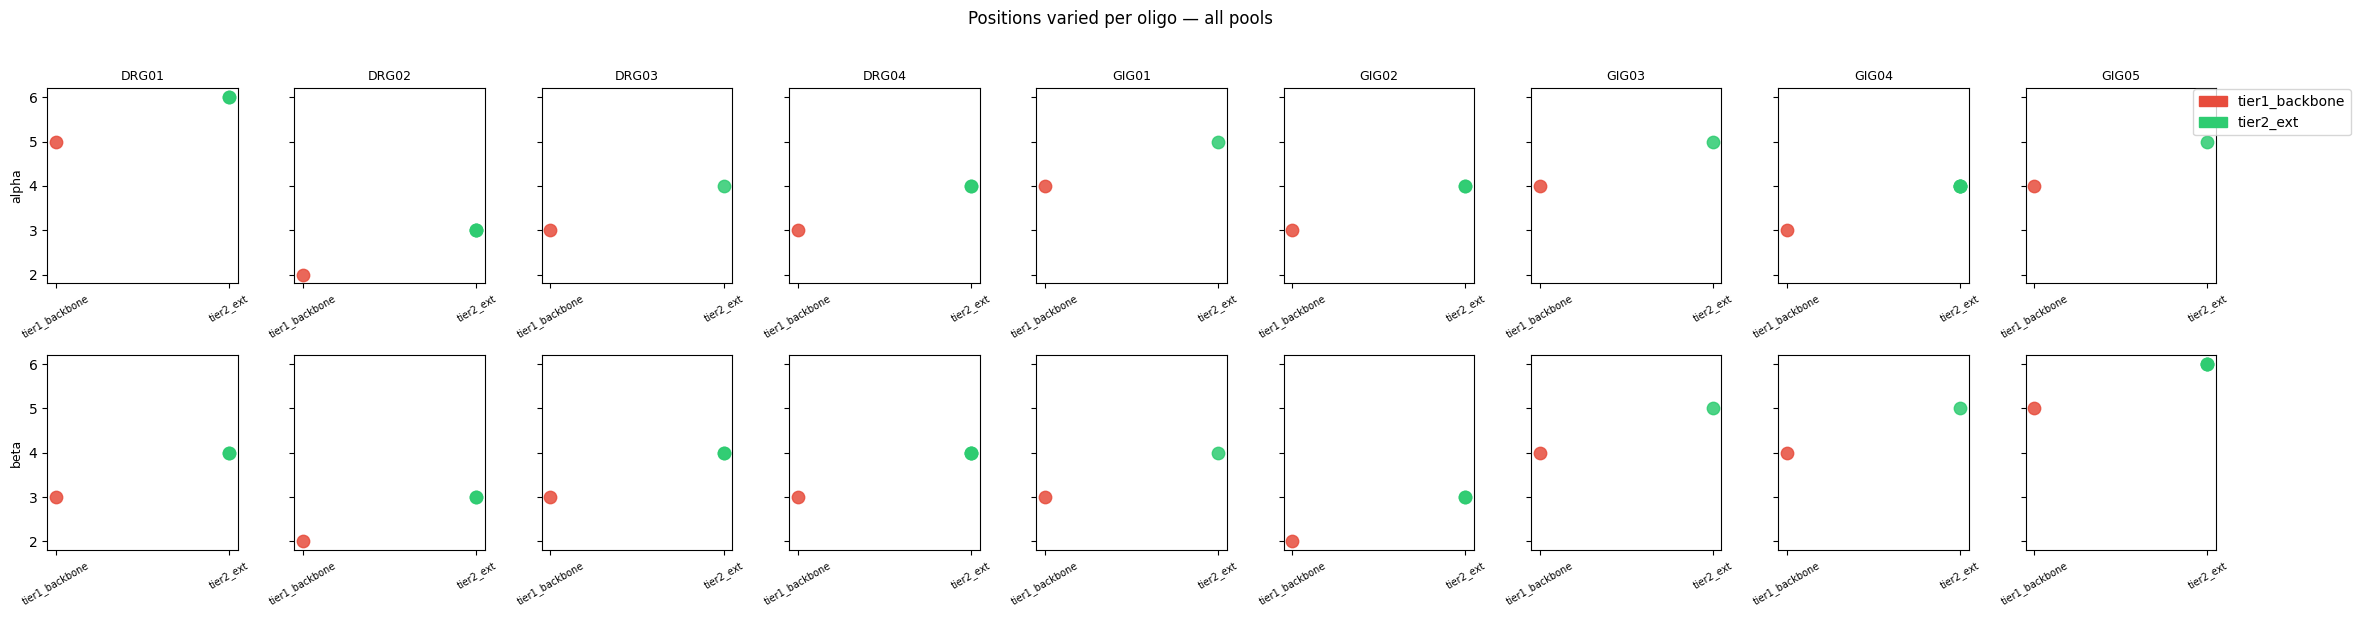

In [45]:
import matplotlib.patches as mpatches

colors = {'tier1_backbone': '#e74c3c', 'tier2_ext': '#2ecc71'}

n_peps = len(PEPTIDES)
fig, axes = plt.subplots(2, n_peps, figsize=(n_peps * 2.5, 6), sharey=True)

for col_i, pep in enumerate(PEPTIDES):
    for row_i, chain in enumerate(['alpha', 'beta']):
        pool_name = f'{chain}_{pep}'
        ax = axes[row_i, col_i]
        pool = POOLS[pool_name]
        for otype, col in colors.items():
            grp = [o['n_varied'] for o in pool if o['oligo_type'] == otype]
            if grp:
                ax.scatter([otype] * len(grp), grp, color=col, s=80, alpha=0.85)
        if row_i == 0:
            ax.set_title(pep, fontsize=9)
        if col_i == 0:
            ax.set_ylabel(chain, fontsize=9)
        ax.tick_params(axis='x', rotation=30, labelsize=7)

handles = [mpatches.Patch(color=c, label=t) for t, c in colors.items()]
fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(1.05, 0.9))
plt.suptitle('Positions varied per oligo — all pools', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'oligo_variability.pdf', bbox_inches='tight')
plt.show()


## Export to CSV

In [46]:
def pool_to_df(pool, chain, wt_seq):
    chain_len = len(wt_seq)
    rows, cumul = [], 0
    for o in pool:
        cumul += o['unique_diversity']
        dna    = ''.join(o['iupac_triplets'][p] for p in range(chain_len))
        varied = {p: sorted(aas)
                  for p, aas in o['position_aas'].items()
                  if len(aas) > 1}
        varied_str = '; '.join(f'p{p}:[{",".join(aas)}]' for p, aas in sorted(varied.items()))
        effs   = [e for e in o['codon_efficiency'].values() if e < 1.0]
        rows.append({
            'oligo_id':              o['oligo_id'],
            'oligo_type':            o['oligo_type'],
            'chain_dna':             dna,
            'dna_length':            len(dna),
            'n_variable_positions':  len(varied),
            'variable_positions':    varied_str,
            'diversity':             o['diversity'],
            'unique_diversity':      o['unique_diversity'],
            'cumulative_diversity':  cumul,
            'mean_codon_efficiency': round(np.mean(effs), 3) if effs else 1.0,
            'is_leaky':              o.get('is_leaky', False),
        })
    return pd.DataFrame(rows)


wt_seqs = {'alpha': WT_ALPHA, 'beta': WT_BETA}
for pool_name, pool in POOLS.items():
    chain = pool_name.split('_')[0]
    df    = pool_to_df(pool, chain, wt_seqs[chain])
    path  = OUT_DIR / f'opool_{pool_name}.csv'
    df.to_csv(path, index=False)
    print(f'Wrote {path}  ({len(df)} oligos)')
    display(df[['oligo_id','oligo_type','n_variable_positions','variable_positions','diversity','unique_diversity']])

Wrote /cluster/project/reddy/marluca/NGS_pipeline/notebooks/opool_designs/opool_alpha_DRG01.csv  (3 oligos)


,oligo_id,oligo_type,n_variable_positions,variable_positions,diversity,unique_diversity
0,alpha_tier1_backbone,tier1_backbone,5,"p0:[A,G]; p1:[A,V]; p3:[F,I,L,M]; p7:[E,K,L,M,...",240,240
1,alpha_ext_p08,tier2_ext,6,"p0:[A,G]; p1:[A,V]; p3:[F,I,L,M]; p7:[E,K,L,M,...",480,240
2,alpha_ext_p02,tier2_ext,6,"p0:[A,G]; p1:[A,V]; p2:[H,N]; p3:[F,I,L,M]; p7...",480,240


Wrote /cluster/project/reddy/marluca/NGS_pipeline/notebooks/opool_designs/opool_beta_DRG01.csv  (3 oligos)


,oligo_id,oligo_type,n_variable_positions,variable_positions,diversity,unique_diversity
0,beta_tier1_backbone,tier1_backbone,3,"p4:[A,L,S,V]; p7:[K,R,T]; p8:[E,I,K,L,Q,V]",72,72
1,beta_ext_p10,tier2_ext,4,"p4:[A,L,S,V]; p7:[K,R,T]; p8:[E,I,K,L,Q,V]; p1...",1008,936
2,beta_ext_p02,tier2_ext,4,"p2:[P,S]; p4:[A,L,S,V]; p7:[K,R,T]; p8:[E,I,K,...",144,72


Wrote /cluster/project/reddy/marluca/NGS_pipeline/notebooks/opool_designs/opool_alpha_DRG02.csv  (4 oligos)


...

,oligo_id,oligo_type,n_variable_positions,variable_positions,diversity,unique_diversity
0,beta_tier1_backbone,tier1_backbone,4,"p2:[G,S]; p3:[I,L,S,T]; p7:[A,G,I,S,T,V]; p8:[...",240,240
1,beta_ext_p04,tier2_ext,5,"p2:[G,S]; p3:[I,L,S,T]; p4:[I,M,R,S,T]; p7:[A,...",1200,960


Wrote /cluster/project/reddy/marluca/NGS_pipeline/notebooks/opool_designs/opool_alpha_GIG05.csv  (2 oligos)


,oligo_id,oligo_type,n_variable_positions,variable_positions,diversity,unique_diversity
0,alpha_tier1_backbone,tier1_backbone,4,"p0:[A,D,G]; p3:[F,I,L,M,V]; p7:[K,L,M,R,W]; p9...",375,375
1,alpha_ext_p01,tier2_ext,5,"p0:[A,D,G]; p1:[A,C,F,G,I,S,T,V]; p3:[F,I,L,M,...",3000,2625


Wrote /cluster/project/reddy/marluca/NGS_pipeline/notebooks/opool_designs/opool_beta_GIG05.csv  (4 oligos)


,oligo_id,oligo_type,n_variable_positions,variable_positions,diversity,unique_diversity
0,beta_tier1_backbone,tier1_backbone,5,"p2:[G,S]; p3:[L,M,V]; p7:[I,S,T]; p8:[A,E]; p1...",144,144
1,beta_ext_p00,tier2_ext,6,"p0:[A,E,G]; p2:[G,S]; p3:[L,M,V]; p7:[I,S,T]; ...",432,288
2,beta_ext_p09,tier2_ext,6,"p2:[G,S]; p3:[L,M,V]; p7:[I,S,T]; p8:[A,E]; p9...",288,144
3,beta_ext_p01,tier2_ext,6,"p1:[A,D,E,H,K,N,P,Q,S,T,Y]; p2:[G,S]; p3:[L,M,...",1584,1440


## QC: Codon Efficiency

In [47]:
for pool_name, pool in POOLS.items():
    effs  = [e for o in pool for e in o['codon_efficiency'].values() if e < 1.0]
    leaky = sum(1 for o in pool if o.get('is_leaky', False))
    if effs:
        print(f'{pool_name:<15}  mean_eff={np.mean(effs):.2f}  min_eff={np.min(effs):.2f}  leaky={leaky}/{len(pool)}')
    else:
        print(f'{pool_name:<15}  no variable positions')

alpha_DRG01      mean_eff=0.52  min_eff=0.40  leaky=0/3
beta_DRG01       mean_eff=0.46  min_eff=0.14  leaky=1/3
alpha_DRG02      mean_eff=0.27  min_eff=0.18  leaky=4/4
beta_DRG02       mean_eff=0.25  min_eff=0.17  leaky=3/3
alpha_DRG03      mean_eff=0.32  min_eff=0.15  leaky=2/2
beta_DRG03       mean_eff=0.38  min_eff=0.22  leaky=3/3
alpha_DRG04      mean_eff=0.40  min_eff=0.29  leaky=3/3
beta_DRG04       mean_eff=0.35  min_eff=0.22  leaky=4/4
alpha_GIG01      mean_eff=0.41  min_eff=0.18  leaky=2/2
beta_GIG01       mean_eff=0.33  min_eff=0.17  leaky=2/2
alpha_GIG02      mean_eff=0.32  min_eff=0.29  leaky=3/3
beta_GIG02       mean_eff=0.26  min_eff=0.17  leaky=3/3
alpha_GIG03      mean_eff=0.39  min_eff=0.29  leaky=2/2
beta_GIG03       mean_eff=0.46  min_eff=0.22  leaky=1/2
alpha_GIG04      mean_eff=0.36  min_eff=0.18  leaky=5/5
beta_GIG04       mean_eff=0.41  min_eff=0.33  leaky=0/2
alpha_GIG05      mean_eff=0.44  min_eff=0.25  leaky=1/2
beta_GIG05       mean_eff=0.58  min_eff=0.18  le

## Per-Oligo Grid Plot

One figure per pool, one panel per oligo.
**■ grey square** = WT residue at that position.
**● coloured circle** = non-WT, coloured by biochemical class.
**Shaded column** = variable position (>1 AA encoded).
Line 2 of x-tick = IUPAC codon used at that variable position.

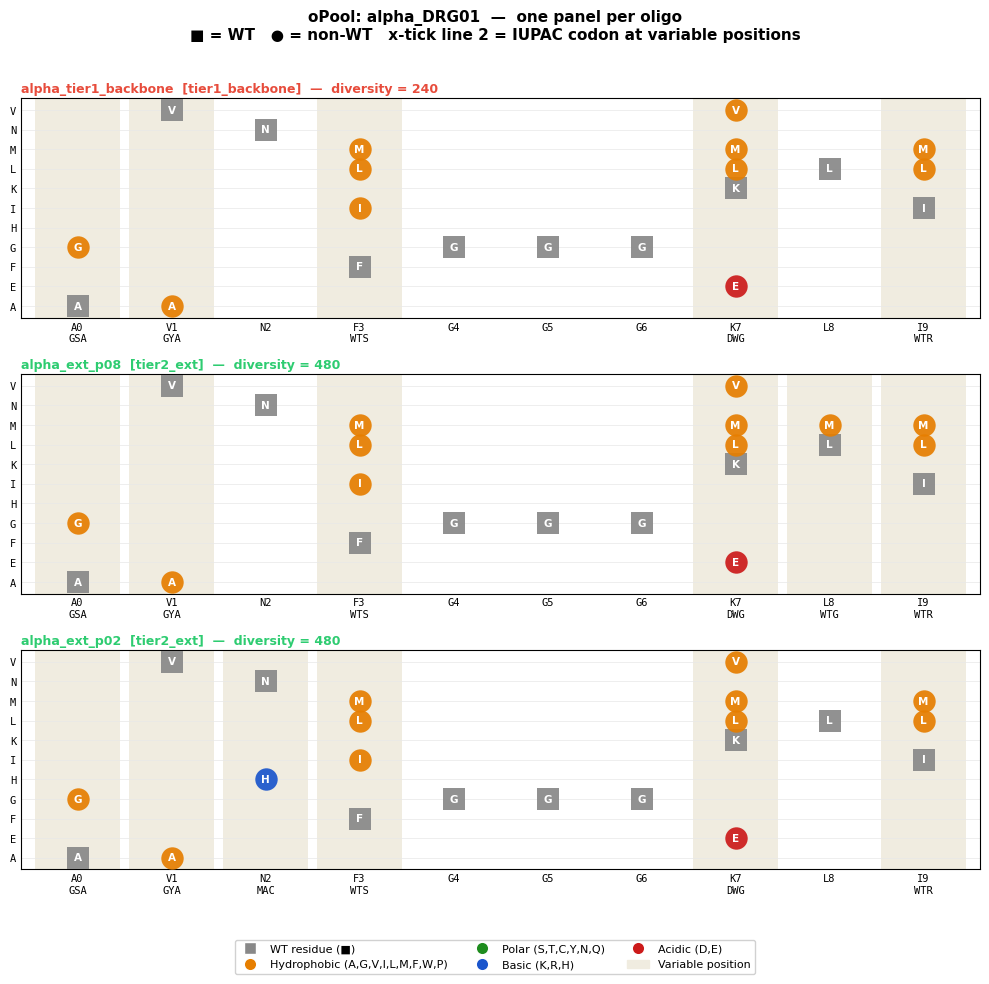

Saved → /cluster/project/reddy/marluca/NGS_pipeline/notebooks/opool_designs/opool_alpha_DRG01_t0.33_per_oligo.pdf


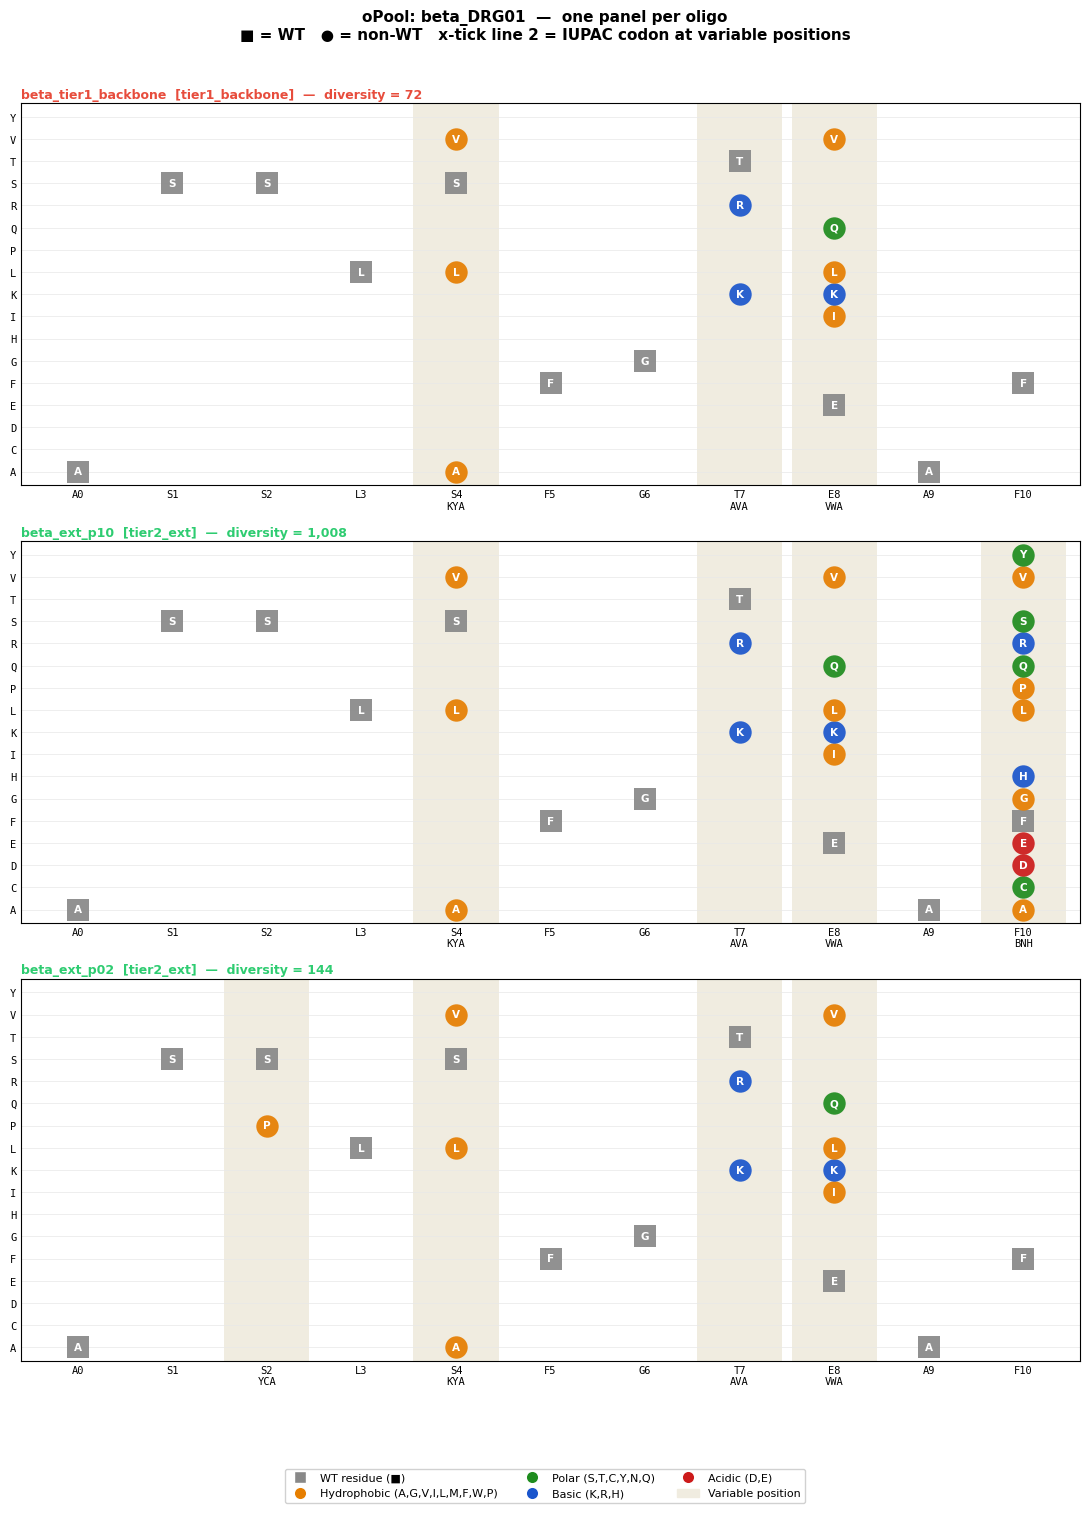

Saved → /cluster/project/reddy/marluca/NGS_pipeline/notebooks/opool_designs/opool_beta_DRG01_t0.33_per_oligo.pdf


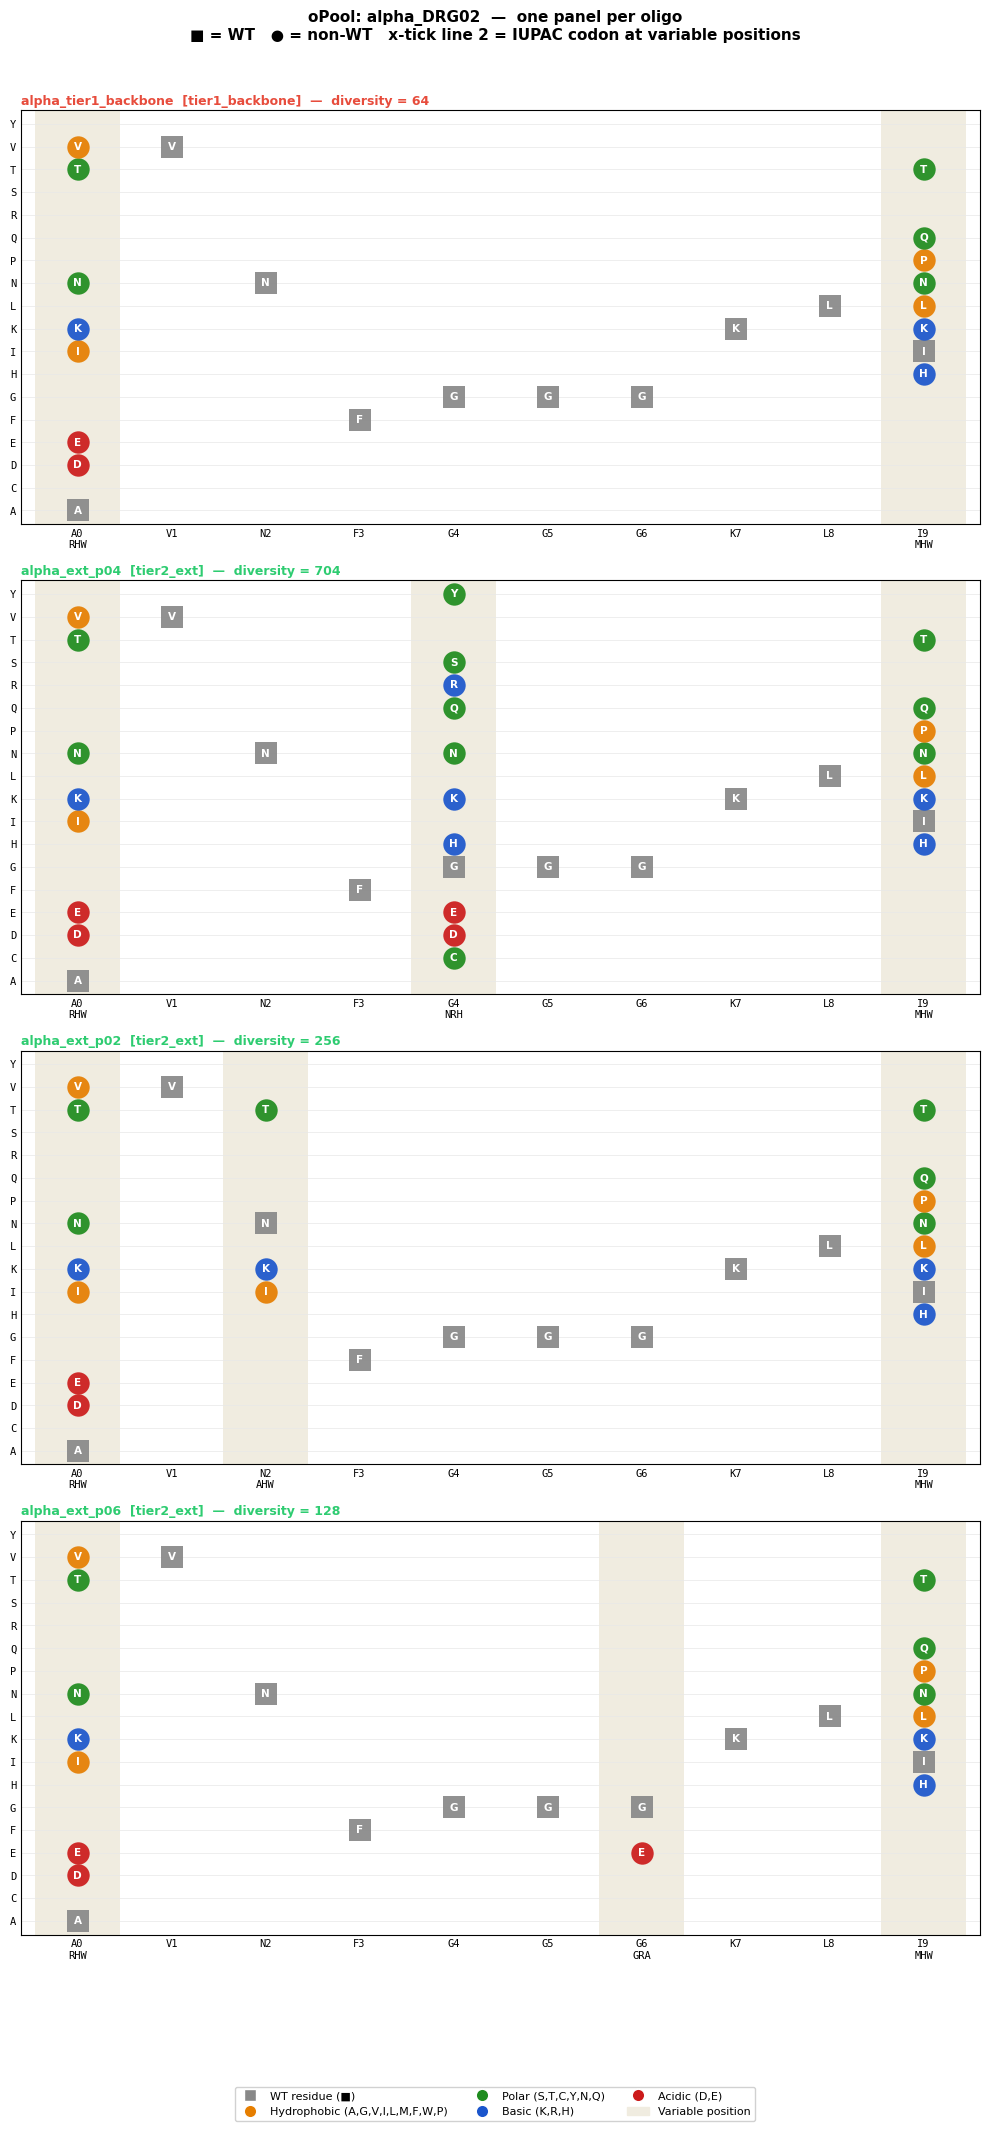

Saved → /cluster/project/reddy/marluca/NGS_pipeline/notebooks/opool_designs/opool_alpha_DRG02_t0.33_per_oligo.pdf


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

AA_CHEM = {
    'A':'#e67e00','G':'#e67e00','V':'#e67e00','I':'#e67e00','L':'#e67e00',
    'M':'#e67e00','F':'#e67e00','W':'#e67e00','P':'#e67e00',
    'S':'#1e8c1e','T':'#1e8c1e','C':'#1e8c1e','Y':'#1e8c1e',
    'N':'#1e8c1e','Q':'#1e8c1e',
    'K':'#1a55cc','R':'#1a55cc','H':'#1a55cc',
    'D':'#cc1a1a','E':'#cc1a1a',
}
WT_COL = '#888888'

OLIGO_TYPE_COLOR = {
    'tier1_backbone': '#e74c3c',
    'tier2_ext':      '#2ecc71',
}


def plot_pool_per_oligo(pool_name, pool, wt_seq):
    chain_len = len(wt_seq)

    all_aas = sorted({
        aa
        for o in pool
        for aas in o['position_aas'].values()
        for aa in aas
    })
    aa_y = {aa: i for i, aa in enumerate(all_aas)}
    n_aa = len(all_aas)

    n_oligos = len(pool)
    row_h    = max(2.5, n_aa * 0.30)
    fig, axes = plt.subplots(
        n_oligos, 1,
        figsize=(max(10, chain_len * 1.0), row_h * n_oligos),
        squeeze=False,
    )

    for ax, oligo in zip(axes[:, 0], pool):
        for pos in range(chain_len):
            if len(oligo['position_aas'][pos]) > 1:
                ax.axvspan(pos - 0.45, pos + 0.45, color='#f0ece0', zorder=0, lw=0)

        for pos in range(chain_len):
            for aa in sorted(oligo['position_aas'][pos]):
                is_wt  = (aa == wt_seq[pos])
                color  = WT_COL if is_wt else AA_CHEM.get(aa, '#555555')
                marker = 's' if is_wt else 'o'
                ax.scatter(pos, aa_y[aa], s=260, color=color,
                           marker=marker, alpha=0.92, zorder=3, linewidths=0)
                ax.text(pos, aa_y[aa], aa, ha='center', va='center',
                        fontsize=7.5, fontweight='bold', color='white', zorder=4)

        ax.set_xlim(-0.6, chain_len - 0.4)
        ax.set_ylim(-0.6, n_aa - 0.4)
        ax.set_xticks(range(chain_len))

        # Line 1: WT residue + position index; line 2: IUPAC codon at variable positions
        xlabels = []
        for i in range(chain_len):
            base = f'{wt_seq[i]}{i}'
            if len(oligo['position_aas'][i]) > 1:
                xlabels.append(f'{base}\n{oligo["iupac_triplets"][i]}')
            else:
                xlabels.append(base)
        ax.set_xticklabels(xlabels, fontsize=7.5, fontfamily='monospace')

        ax.set_yticks(range(n_aa))
        ax.set_yticklabels(all_aas, fontsize=7.5, fontfamily='monospace')
        ax.tick_params(axis='x', length=0, pad=3)
        ax.tick_params(axis='y', length=0)
        ax.set_axisbelow(True)
        ax.yaxis.grid(True, color='#e8e8e8', linewidth=0.5)

        otype = oligo['oligo_type']
        tc    = OLIGO_TYPE_COLOR.get(otype, '#555')
        ax.set_title(
            f"{oligo['oligo_id']}  [{otype}]  —  diversity = {oligo['diversity']:,}",
            fontsize=9, loc='left', pad=4, color=tc, fontweight='bold',
        )

    legend_handles = [
        mlines.Line2D([], [], marker='s', color='w', markerfacecolor=WT_COL,
                      markersize=9, label='WT residue (\u25a0)'),
        mlines.Line2D([], [], marker='o', color='w', markerfacecolor='#e67e00',
                      markersize=9, label='Hydrophobic (A,G,V,I,L,M,F,W,P)'),
        mlines.Line2D([], [], marker='o', color='w', markerfacecolor='#1e8c1e',
                      markersize=9, label='Polar (S,T,C,Y,N,Q)'),
        mlines.Line2D([], [], marker='o', color='w', markerfacecolor='#1a55cc',
                      markersize=9, label='Basic (K,R,H)'),
        mlines.Line2D([], [], marker='o', color='w', markerfacecolor='#cc1a1a',
                      markersize=9, label='Acidic (D,E)'),
        mpatches.Patch(color='#f0ece0', label='Variable position'),
    ]
    fig.legend(handles=legend_handles, loc='lower center', ncol=3,
               fontsize=8, bbox_to_anchor=(0.5, 0.0), framealpha=0.9)

    fig.suptitle(
        f'oPool: {pool_name}  —  one panel per oligo\n'
        f'\u25a0 = WT   \u25cf = non-WT   x-tick line 2 = IUPAC codon at variable positions',
        fontsize=11, fontweight='bold',
    )
    plt.tight_layout(rect=[0, 0.07, 1, 0.97])

    pdf = OUT_DIR / f'opool_{pool_name}_t{TIER1_FRAC}_per_oligo.pdf'
    png = OUT_DIR / f'opool_{pool_name}_t{TIER1_FRAC}_per_oligo.png'
    plt.savefig(pdf, bbox_inches='tight')
    plt.savefig(png, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Saved \u2192 {pdf}')


wt_seqs = {'alpha': WT_ALPHA, 'beta': WT_BETA}
for pool_name, pool in POOLS.items():
    wt_seq = wt_seqs[pool_name.split('_')[0]]
    plot_pool_per_oligo(pool_name, pool, wt_seq)
